# Multi Agent
## Supervisor Pattern
'중앙 관리자 에이전트가 하위 특화 에이전트에게 일을 시킴

> 관리자 Agent > 캘린더 agent / 이메일 agent

In [17]:
from dotenv import load_dotenv
load_dotenv()

True

### Calendar Agent

In [18]:
from langchain.tools import tool

@tool
def create_calendar_event(
    title: str,
    start_time: str,       # ISO format: "2024-01-15T14:00:00"
    end_time: str,         # ISO format: "2024-01-15T15:00:00"
    attendees: list[str],  # email addresses
    location: str = ""
) -> str:
    """Create a calendar event. Requires exact ISO datetime format."""
    # Stub: In practice, this would call Google Calendar API, Outlook API, etc.
    return f"Event created: {title} from {start_time} to {end_time} with {len(attendees)} attendees"


@tool
def get_available_time_slots(
    attendees: list[str],
    date: str,  # ISO format: "2024-01-15"
    duration_minutes: int
) -> list[str]:
    """Check calendar availability for given attendees on a specific date."""
    # Stub: In practice, this would query calendar APIs
    return ["09:00", "14:00", "16:00"]


from datetime import date

CALENDAR_AGENT_PROMPT = (
    f"Today's date is {date.today().isoformat()}. "
    "You are a calendar scheduling assistant. "
    "Parse natural language scheduling requests (e.g., 'next Tuesday at 2pm') "
    "into proper ISO datetime formats. "
    "Use get_available_time_slots to check availability when needed. "
    "If there is no suitable time slot, stop and confirm unavailability in your response. "
    "Use create_calendar_event to schedule events. "
    "Always confirm what was scheduled in your final response."
)

### Email Agent

In [19]:
@tool
def send_email(
    to: list[str],  # email addresses
    subject: str,
    body: str,
    cc: list[str] = []
) -> str:
    """Send an email via email API. Requires properly formatted addresses."""
    # Stub: In practice, this would call SendGrid, Gmail API, etc.
    return f"Email sent to {', '.join(to)} - Subject: {subject}"

EMAIL_AGENT_PROMPT = (
    "You are an email assistant. "
    "Compose professional emails based on natural language requests. "
    "Extract recipient information and craft appropriate subject lines and body text. "
    "Use send_email to send the message. "
    "Always confirm what was sent in your final response."
)


### Member Agent

In [20]:
@tool
def retrieve_member_info(sql_query: str, team:str = None) -> list[dict]:
    """
    주어진 PostgreSQL 쿼리를 실행하여 멤버(회원/직원) 정보를 데이터베이스에서 조회합니다.
    조회 결과로 id, name, email, team 정보를 포함하는 리스트를 반환합니다.
    team 을 입력할 경우, 해당 team 의 멤버들만 가져옵니다.
    """
    # 요청된 쿼리에 관계없이 가짜(Fake) 데이터를 반환하도록 구성된 목(Mock) 데이터입니다.
    # 기획팀, 영업팀, 개발팀 각각 3명씩 총 9명
    fake_db = [
        {"id": 1, "name": "김기획", "email": "plan1@example.com", "team": "기획팀"},
        {"id": 2, "name": "이기획", "email": "plan2@example.com", "team": "기획팀"},
        {"id": 3, "name": "박기획", "email": "plan3@example.com", "team": "기획팀"},
        {"id": 4, "name": "최영업", "email": "sales1@example.com", "team": "영업팀"},
        {"id": 5, "name": "정영업", "email": "sales2@example.com", "team": "영업팀"},
        {"id": 6, "name": "강영업", "email": "sales3@example.com", "team": "영업팀"},
        {"id": 7, "name": "조개발", "email": "dev1@example.com", "team": "개발팀"},
        {"id": 8, "name": "윤개발", "email": "dev2@example.com", "team": "개발팀"},
        {"id": 9, "name": "장개발", "email": "dev3@example.com", "team": "개발팀"},
    ]
    # 실제 환경이라면 여기서 sql_query를 DB에 날리겠지만, 여기서는 그대로 반환합니다.
    return list(filter(lambda m: m['team'] == team, fake_db)) if team else fake_db


MEMBER_AGENT_PROMPT = (
    "You are a database specialist assistant. "
    "Your task is to retrieve member/employee information from the database based on user requests. "
    "You must write and execute SQL queries using the `retrieve_member_info` tool.\n\n"
    "### Database Environment\n"
    "- SQL Dialect: PostgreSQL\n"
    "- Table Schema: `members` table has the following columns:\n"
    "  * id (SERIAL PRIMARY KEY)\n"
    "  * name (VARCHAR)\n"
    "  * email (VARCHAR)\n"
    "  * team (VARCHAR)\n\n"
    "### Constraints\n"
    "- STRICTLY READ-ONLY: You must ONLY execute READ (SELECT) operations. "
    "- Do NOT execute any INSERT, UPDATE, DELETE, or DROP queries under any circumstances.\n"
    "- Always summarize the retrieved data naturally in your final response."
)



In [21]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


supervisor_llm = init_chat_model('openai:gpt-5.4-mini')
worker_llm = init_chat_model('openai:gpt-4.1-mini')

calendar_agent = create_agent(
    model=worker_llm,
    tools=[create_calendar_event, get_available_time_slots],
    system_prompt=CALENDAR_AGENT_PROMPT,
    middleware=[
        HumanInTheLoopMiddleware(
            # 어느 지점에서 멈출것이냐? -> 캘린더이벤트생성 직전
            interrupt_on={'create_calendar_event': True,},
            description_prefix="캘린더 이벤트 승인 대기중..!!"
        )
    ]
)

email_agent = create_agent(
    model=worker_llm,
    tools=[send_email],
    system_prompt=EMAIL_AGENT_PROMPT,
    middleware=[
        HumanInTheLoopMiddleware(
            # 어느 지점에서 멈출것이냐? -> 캘린더이벤트생성 직전
            interrupt_on={'send_email': True,},
            description_prefix="이메일 발신 승인 대기중..!!"
        )
    ]
)

member_agent = create_agent(
    model=worker_llm,
    tools=[retrieve_member_info],
    system_prompt=MEMBER_AGENT_PROMPT
)

In [22]:
@tool
def schedule_event(request: str) -> str:
    """Schedule calendar events using natural language.

    Use this when the user wants to create, modify, or check calendar appointments.
    Handles date/time parsing, availability checking, and event creation.

    Input: Natural language scheduling request (e.g., 'meeting with design team
    next Tuesday at 2pm')
    """
    result = calendar_agent.invoke({
        "messages": [HumanMessage(request)]
    })
    return result["messages"][-1].text


@tool
def manage_email(request: str) -> str:
    """Send emails using natural language.

    Use this when the user wants to send notifications, reminders, or any email
    communication. Handles recipient extraction, subject generation, and email
    composition.

    Input: Natural language email request (e.g., 'send them a reminder about
    the meeting')
    """
    result = email_agent.invoke({
        "messages": [HumanMessage(request)]
    })
    return result["messages"][-1].text


@tool
def get_members(request: str) -> str:
    """Search and retrieve member information from DB using natural language.
    
    Use this when the user wants to find details about employees or members, 
    such as their names, email addresses, teams, or IDs. Handles natural 
    language queries regarding organizational members.

    Input: Natural language member search request (e.g., '개발팀 멤버들의 이메일을 알려줘' or 'Find the emails of the design team')
    """
    result = member_agent.invoke({
        'messages': [HumanMessage(request)]
    })
    return result['messages'][-1].text

In [24]:
SUPERVISOR_PROMPT = (
    "You are a helpful personal assistant. "
    "You can schedule calendar events, search members and send emails. "
    "If you need to check team's member info, you should search member info. Mail Address are in DB"
    "Break down user requests into appropriate tool calls and coordinate the results. "
    "When a request involves multiple actions, use multiple tools in sequence or in parallel as appropriate."
)


supervisor_agent = create_agent(
    model=supervisor_llm,
    tools=[manage_email, schedule_event, get_members],
    system_prompt=SUPERVISOR_PROMPT,
    checkpointer=InMemorySaver()
)

In [25]:
query = (
    "Schedule a meeting with the design team next Tuesday at 2pm for 1 hour, "
    "and send them an email reminder about reviewing the new mockups."
)

config = {"configurable": {"thread_id": "6"}}

interrupts = []
stream = supervisor_agent.stream_events(
    {"messages": [{"role": "user", "content": query}]},
    config,
    version="v3",
)
for kind, item in stream.interleave("messages", "tool_calls"):
    if kind == "messages":
        for token in item.text:
            print(token, end="", flush=True)
    elif kind == "tool_calls":
        print(f"\nTool call: {item.tool_name}({item.input})")
if stream.interrupted:
    for interrupt_ in stream.interrupts:
        interrupts.append(interrupt_)
        print(f"\nINTERRUPTED: {interrupt_.id}")

c:\Users\sesac_seocho\Desktop\gaida-3\.venv\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
c:\Users\sesac_seocho\Desktop\gaida-3\.venv\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)



Tool call: schedule_event({'request': 'Schedule a meeting with the design team next Tuesday at 2pm for 1 hour.'})

Tool call: manage_email({'request': 'Send an email reminder to the design team about reviewing the new mockups.'})

INTERRUPTED: cdcda45d2762d1f4afb46029d7484716

INTERRUPTED: ee81a551e03746942be09d1c95e06496


In [26]:
for interrupt_ in interrupts:
    for request in interrupt_.value["action_requests"]:
        print(f"INTERRUPTED: {interrupt_.id}")
        print(f"{request['description']}\n")

INTERRUPTED: cdcda45d2762d1f4afb46029d7484716
이메일 발신 승인 대기중..!!

Tool: send_email
Args: {'to': ['design_team@example.com'], 'subject': 'Reminder: Review New Mockups', 'body': 'Dear Design Team,\n\nThis is a friendly reminder to review the new mockups at your earliest convenience. Please make sure to provide your feedback and comments.\n\nThank you for your attention to this matter.\n\nBest regards,\n[Your Name]'}

INTERRUPTED: ee81a551e03746942be09d1c95e06496
캘린더 이벤트 승인 대기중..!!

Tool: create_calendar_event
Args: {'title': 'Meeting with Design Team', 'start_time': '2026-09-22T14:00:00', 'end_time': '2026-09-22T15:00:00', 'attendees': ['design team']}



In [27]:
from langgraph.types import Command

resume = {}
for interrupt_ in interrupts:
    if interrupt_.id == "cdcda45d2762d1f4afb46029d7484716":
        # Edit email
        edited_action = interrupt_.value["action_requests"][0].copy()
        edited_action["args"]["subject"] = "Mockups reminder"
        resume[interrupt_.id] = {
            "decisions": [{"type": "edit", "edited_action": edited_action}]
        }
    else:
        resume[interrupt_.id] = {"decisions": [{"type": "approve"}]}

interrupts = []
stream = supervisor_agent.stream_events(
    Command(resume=resume),
    config,
    version="v3",
)
for kind, item in stream.interleave("messages", "tool_calls"):
    if kind == "messages":
        for token in item.text:
            print(token, end="", flush=True)
    elif kind == "tool_calls":
        print(f"\nTool call: {item.tool_name}({item.input})")
if stream.interrupted:
    for interrupt_ in stream.interrupts:
        interrupts.append(interrupt_)
        print(f"\nINTERRUPTED: {interrupt_.id}")


Tool call: schedule_event({'request': 'Schedule a meeting with the design team next Tuesday at 2pm for 1 hour.'})

Tool call: manage_email({'request': 'Send an email reminder to the design team about reviewing the new mockups.'})
Done — I scheduled the meeting for next Tuesday from 2:00 PM to 3:00 PM and sent the reminder email about reviewing the new mockups.

## State Machine Pattern
- State 를 확장
- 1개의 agent 가 state 에 따라서 다른 행동을 함
- 행동은 Prompt, Tool 목록으로 바꿈
- 1개의 Agent 가 여러 Agent 처럼 행동
- Tool -> Agent 로 `Command`를 통해 state 를 변경

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
# 커스텀 agent state 생성

from langchain.agents import AgentState
from typing_extensions import NotRequired
from typing import Literal

# Define the possible workflow steps
SupportStep = Literal["warranty_collector", "issue_classifier", "resolution_specialist"]

class SupportState(AgentState):
    """State for customer support workflow."""
    # messages 있음
    current_step: NotRequired[SupportStep]
    warranty_status: NotRequired[Literal["in_warranty", "out_of_warranty"]]
    issue_type: NotRequired[Literal["hardware", "software"]]

In [ ]:
from langchain.tools import tool, ToolRuntime
from langchain.messages import ToolMessage
from langgraph.types import Command

@tool
def record_warranty_status(
    status: Literal["in_warranty", "out_of_warranty"],
    runtime: ToolRuntime[None, SupportState],
) -> Command:
    """Record the customer's warranty status and transition to issue classification."""
    return Command(  # agent에게 "명령" 하는것. -> Agent의 State를 바꿈.
        update={
            "messages": [
                ToolMessage(
                    content=f"Warranty status recorded as: {status}",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
            "warranty_status": status,
            "current_step": "issue_classifier",  # 다음 스텝을 결정하는
        }
    )


@tool
def record_issue_type(
    issue_type: Literal["hardware", "software"],
    runtime: ToolRuntime[None, SupportState],
) -> Command:
    """Record the type of issue and transition to resolution specialist."""
    return Command(
        update={
            "messages": [
                ToolMessage(
                    content=f"Issue type recorded as: {issue_type}",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
            "issue_type": issue_type,
            "current_step": "resolution_specialist",
        }
    )


@tool
def escalate_to_human(reason: str) -> str:
    """Escalate the case to a human support specialist."""
    # In a real system, this would create a ticket, notify staff, etc.
    return f"Escalating to human support. Reason: {reason}"


@tool
def provide_solution(solution: str) -> str:
    """Provide a solution to the customer's issue."""
    return f"Solution provided: {solution}"

In [ ]:
# Define prompts as constants for easy reference
WARRANTY_COLLECTOR_PROMPT = """You are a customer support agent helping with device issues.

CURRENT STAGE: Warranty verification

At this step, you need to:
1. Greet the customer warmly
2. Ask if their device is under warranty
3. Use record_warranty_status to record their response and move to the next step

Be conversational and friendly. Don't ask multiple questions at once."""

ISSUE_CLASSIFIER_PROMPT = """You are a customer support agent helping with device issues.

CURRENT STAGE: Issue classification
CUSTOMER INFO: Warranty status is {warranty_status}

At this step, you need to:
1. Ask the customer to describe their issue
2. Determine if it's a hardware issue (physical damage, broken parts) or software issue (app crashes, performance)
3. Use record_issue_type to record the classification and move to the next step

If unclear, ask clarifying questions before classifying."""

RESOLUTION_SPECIALIST_PROMPT = """You are a customer support agent helping with device issues.

CURRENT STAGE: Resolution
CUSTOMER INFO: Warranty status is {warranty_status}, issue type is {issue_type}

At this step, you need to:
1. For SOFTWARE issues: provide troubleshooting steps using provide_solution
2. For HARDWARE issues:
   - If IN WARRANTY: explain warranty repair process using provide_solution
   - If OUT OF WARRANTY: escalate_to_human for paid repair options

Be specific and helpful in your solutions."""

In [ ]:
# Step configuration: maps step name to (prompt, tools, required_state)
STEP_CONFIG = {
    "warranty_collector": {
        "prompt": WARRANTY_COLLECTOR_PROMPT,
        "tools": [record_warranty_status],
        "requires": [],
    },
    "issue_classifier": {
        "prompt": ISSUE_CLASSIFIER_PROMPT,
        "tools": [record_issue_type],
        "requires": ["warranty_status"],
    },
    "resolution_specialist": {
        "prompt": RESOLUTION_SPECIALIST_PROMPT,
        "tools": [provide_solution, escalate_to_human],
        "requires": ["warranty_status", "issue_type"],
    },
}

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable


@wrap_model_call
def apply_step_config(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """Configure agent behavior based on the current step."""
    # Get current step (defaults to warranty_collector for first interaction)
    current_step = request.state.get("current_step", "warranty_collector")

    # Look up step configuration
    stage_config = STEP_CONFIG[current_step]

    # Validate required state exists
    for key in stage_config["requires"]:
        if request.state.get(key) is None:
            raise ValueError(f"{key} must be set before reaching {current_step}")

    # Format prompt with state values (supports {warranty_status}, {issue_type}, etc.)
    system_prompt = stage_config["prompt"].format(**request.state)

    # Inject system prompt and step-specific tools
    request = request.override(
        system_prompt=system_prompt,
        tools=stage_config["tools"],
    )

    return handler(request)

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model

model = init_chat_model('openai:gpt-4.1-mini')

# Collect all tools from all step configurations
all_tools = [
    record_warranty_status,
    record_issue_type,
    provide_solution,
    escalate_to_human,
]

# Create the agent with step-based configuration
agent = create_agent(
    model,
    tools=all_tools,
    state_schema=SupportState, # 커스텀 state 주입
    middleware=[apply_step_config],  # 미들웨어 -> 페르소나 갈아끼기
    checkpointer=InMemorySaver(),
)

In [ ]:
from langchain.messages import HumanMessage
from langchain_core.utils.uuid import uuid7

# Configuration for this conversation thread
thread_id = str(uuid7())
config = {"configurable": {"thread_id": thread_id}}

In [ ]:
# Turn 1: Initial message - starts with warranty_collector step
print("=== Turn 1: Warranty Collection ===")
result = agent.invoke(
    {"messages": [HumanMessage("Hi, my phone screen is cracked")]},
    config
)
for msg in result['messages']:
    msg.pretty_print()

In [ ]:
# Turn 2: User responds about warranty
print("\n=== Turn 2: Warranty Response ===")
result = agent.invoke(
    {"messages": [HumanMessage("Yes, it's still under warranty")]},
    config
)
for msg in result['messages']:
    msg.pretty_print()
print(f"Current step: {result.get('current_step')}")

In [ ]:
# Turn 3: User describes the issue
print("\n=== Turn 3: Issue Description ===")
result = agent.invoke(
    {"messages": [HumanMessage("The screen is physically cracked from dropping it")]},
    config
)
for msg in result['messages']:
    msg.pretty_print()
print(f"Current step: {result.get('current_step')}")


In [ ]:
# Turn 4: Resolution
print("\n=== Turn 4: Resolution ===")
result = agent.invoke(
    {"messages": [HumanMessage("What should I do?")]},
    config
)
for msg in result['messages']:
    msg.pretty_print()

## Router Pattern
- 분류기 -> 여러 특화 Agent로 구성
- 서로 다른 지식(data)가 각기 다른 영역에 있을 때 유용
- **병렬 실행**
- 선택적 특화 Agent 라우팅
- 깔끔한 종합 답변이 가능

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
from typing import Annotated, Literal, TypedDict
import operator


class AgentInput(TypedDict):
    """Simple input state for each subagent."""
    query: str


class AgentOutput(TypedDict):
    """Output from each subagent."""
    source: str
    result: str


class Classification(TypedDict):
    """A single routing decision: which agent to call with what query."""
    source: Literal["github", "notion", "slack"]
    query: str


class RouterState(TypedDict):
    query: str
    classifications: list[Classification]
    results: Annotated[list[AgentOutput], operator.add]  # Reducer collects parallel results
    final_answer: str

In [ ]:
from langchain.tools import tool


@tool
def search_code(query: str, repo: str = "main") -> str:
    """Search code in GitHub repositories."""
    return f"Found code matching '{query}' in {repo}: authentication middleware in src/auth.py"


@tool
def search_issues(query: str) -> str:
    """Search GitHub issues and pull requests."""
    return f"Found 3 issues matching '{query}': #142 (API auth docs), #89 (OAuth flow), #203 (token refresh)"


@tool
def search_prs(query: str) -> str:
    """Search pull requests for implementation details."""
    return f"PR #156 added JWT authentication, PR #178 updated OAuth scopes"


@tool
def search_notion(query: str) -> str:
    """Search Notion workspace for documentation."""
    return f"Found documentation: 'API Authentication Guide' - covers OAuth2 flow, API keys, and JWT tokens"


@tool
def get_page(page_id: str) -> str:
    """Get a specific Notion page by ID."""
    return f"Page content: Step-by-step authentication setup instructions"


@tool
def search_slack(query: str) -> str:
    """Search Slack messages and threads."""
    return f"Found discussion in #engineering: 'Use Bearer tokens for API auth, see docs for refresh flow'"


@tool
def get_thread(thread_id: str) -> str:
    """Get a specific Slack thread."""
    return f"Thread discusses best practices for API key rotation"

In [9]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

model = init_chat_model("openai:gpt-5.5")

github_agent = create_agent(
    model,
    tools=[search_code, search_issues, search_prs],
    system_prompt=(
        "You are a GitHub expert. Answer questions about code, "
        "API references, and implementation details by searching "
        "repositories, issues, and pull requests."
    ),
)

notion_agent = create_agent(
    model,
    tools=[search_notion, get_page],
    system_prompt=(
        "You are a Notion expert. Answer questions about internal "
        "processes, policies, and team documentation by searching "
        "the organization's Notion workspace."
    ),
)

slack_agent = create_agent(
    model,
    tools=[search_slack, get_thread],
    system_prompt=(
        "You are a Slack expert. Answer questions by searching "
        "relevant threads and discussions where team members have "
        "shared knowledge and solutions."
    ),
)

In [ ]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

router_llm = init_chat_model("openai:gpt-5.4-mini")


# Define structured output schema for the classifier
class ClassificationResult(BaseModel):
    """Result of classifying a user query into agent-specific sub-questions."""
    classifications: list[Classification] = Field(
        description="List of agents to invoke with their targeted sub-questions"
    )


def classify_query(state: RouterState) -> dict:
    """Classify query and determine which agents to invoke."""
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """Analyze this query and determine which knowledge bases to consult.
For each relevant source, generate a targeted sub-question optimized for that source.

Available sources:
- github: Code, API references, implementation details, issues, pull requests
- notion: Internal documentation, processes, policies, team wikis
- slack: Team discussions, informal knowledge sharing, recent conversations

Return ONLY the sources that are relevant to the query. Each source should have
a targeted sub-question optimized for that specific knowledge domain.

Example for "How do I authenticate API requests?":
- github: "What authentication code exists? Search for auth middleware, JWT handling"
- notion: "What authentication documentation exists? Look for API auth guides"
(slack omitted because it's not relevant for this technical question)"""
        },
        {"role": "user", "content": state["query"]}
    ])

    return {"classifications": result.classifications}


# Conditional Edge
def route_to_agents(state: RouterState) -> list[Send]:
    """Fan out to agents based on classifications."""
    return [
        # 경우에 따라(conditional) 실행될 다음 노드 결정 + state 세팅
        Send(c["source"], {"query": c["query"]}) 
        for c in state["classifications"]
    ]


def query_github(state: AgentInput) -> dict:
    """Query the GitHub agent."""
    result = github_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "github", "result": result["messages"][-1].content}]}


def query_notion(state: AgentInput) -> dict:
    """Query the Notion agent."""
    result = notion_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "notion", "result": result["messages"][-1].content}]}


def query_slack(state: AgentInput) -> dict:
    """Query the Slack agent."""
    result = slack_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "slack", "result": result["messages"][-1].content}]}


def synthesize_results(state: RouterState) -> dict:
    """Combine results from all agents into a coherent answer."""
    if not state["results"]:
        return {"final_answer": "No results found from any knowledge source."}

    # Format results for synthesis
    formatted = [
        f"**From {r['source'].title()}:**\n{r['result']}"
        for r in state["results"]
    ]

    synthesis_response = router_llm.invoke([
        {
            "role": "system",
            "content": f"""Synthesize these search results to answer the original question: "{state['query']}"

- Combine information from multiple sources without redundancy
- Highlight the most relevant and actionable information
- Note any discrepancies between sources
- Keep the response concise and well-organized"""
        },
        {"role": "user", "content": "\n\n".join(formatted)}
    ])

    return {"final_answer": synthesis_response.content}

In [13]:
workflow = (
    StateGraph(RouterState)
    .add_node("classify", classify_query)
    .add_node("github", query_github)
    .add_node("notion", query_notion)
    .add_node("slack", query_slack)
    .add_node("synthesize", synthesize_results)
    .add_edge(START, "classify")
    .add_conditional_edges(
        "classify",
        route_to_agents,
        {
            "github": "github",
            'notion': 'notion',
            'slack': 'slack',
        }
    )
    .add_edge("github", "synthesize")
    .add_edge("notion", "synthesize")
    .add_edge("slack", "synthesize")
    .add_edge("synthesize", END)
    .compile()
)

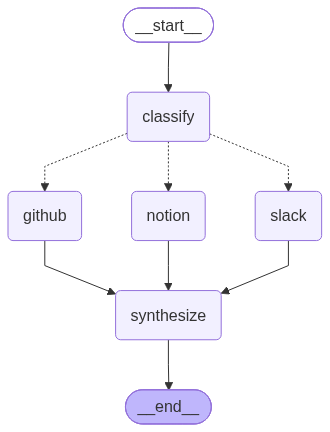

In [14]:
workflow

In [15]:
result = workflow.invoke({
    "query": "How do I authenticate API requests?"
})

print("Original query:", result["query"])
print("\nClassifications:")
for c in result["classifications"]:
    print(f"  {c['source']}: {c['query']}")
print("\n" + "=" * 60 + "\n")
print("Final Answer:")
print(result["final_answer"])

Original query: How do I authenticate API requests?

Classifications:
  github: What authentication code exists for API requests? Search for auth middleware, JWT/OAuth handling, API key validation, request signing, and examples of how clients authenticate.
  notion: What internal documentation exists for API request authentication? Look for API authentication guides, security standards, onboarding docs, and approved authentication methods.


Final Answer:
To authenticate API requests, the relevant implementation appears to be **JWT bearer-token auth via FastAPI OAuth2 password flow**, centralized in **`src/auth.py`**.

## Recommended request flow

1. **Obtain a token** by posting username/password to the token endpoint:
```http
POST /token
Content-Type: application/x-www-form-urlencoded

username=<user>&password=<password>
```

2. **Use the returned JWT** in the `Authorization` header on subsequent requests:
```http
Authorization: Bearer <access_token>
```

Example:
```bash
curl -X POS

In [ ]:
{
    "classifications":[
        {"source":"github","query":"What authentication code exists for API requests? Search for auth middleware, JWT/OAuth handling, API key validation, request signing, and examples of how clients authenticate."},
        {"source":"notion","query":"What internal documentation exists for API request authentication? Look for API authentication guides, security standards, onboarding docs, and approved authentication methods."}
    ]
}